# Iris Species Classification: Model Selection and Evaluation

## Objective

To compare multiple machine learning models on the Iris dataset and determine which model performs best using evaluation metrics and cross-validation.

### Import Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


### Load Dataset

In [3]:
iris = load_iris()

X= iris.data
y= iris.target

### Dataset Overview

In [4]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (150, 4)
Target Shape: (150,)


In [5]:
# Train Test Split
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.2 , random_state=42)

### Model 1

In [6]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)

In [7]:
# Evaluate Logistic Regression
print("Logistic Regression")

print("Accuracy Score:", accuracy_score(y_test, lr_pred))

print("Precision:", precision_score(y_test,lr_pred, average="weighted"))

print("Recall:", recall_score(y_test,lr_pred, average= "weighted"))

print("F1 Score:", f1_score(y_test,lr_pred, average="weighted"))

Logistic Regression
Accuracy Score: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


### Model 2

In [8]:
dt= DecisionTreeClassifier(random_state= 42)

dt.fit(X_train,y_train)

dt_pred=dt.predict(X_test)

In [9]:
# Evaluate Decision Tree Classifier
print("Decision Tree Classifier")

print("Accuracy Score:", accuracy_score(y_test,dt_pred))

print("Precision:", precision_score(y_test,dt_pred, average="weighted"))

print("Recall:", recall_score(y_test,dt_pred, average="weighted"))

print("F1 Score:", f1_score(y_test,dt_pred, average="weighted"))

Decision Tree Classifier
Accuracy Score: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


### Model 3

In [10]:
rf= RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

In [11]:
# Evaluate Random Forest
print("RandomForestClassifier")

print("Accuracy Score:", accuracy_score(y_test, rf_pred))

print("Precision:", precision_score(y_test,rf_pred, average="weighted"))

print("Recall:", recall_score(y_test,rf_pred, average="weighted"))

print("F1 Score:", f1_score(y_test,rf_pred, average="weighted"))

RandomForestClassifier
Accuracy Score: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


### Cross Validation

In [12]:
models={
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf
}
for name, model in models.items():

    scores=cross_val_score(model, X,y, cv=5)

    print(name)

    print("Cross Validation Accuracy:", scores.mean())

    print()

Logistic Regression
Cross Validation Accuracy: 0.9733333333333334

Decision Tree
Cross Validation Accuracy: 0.9533333333333334

Random Forest
Cross Validation Accuracy: 0.9666666666666668



### Confusion Matrix

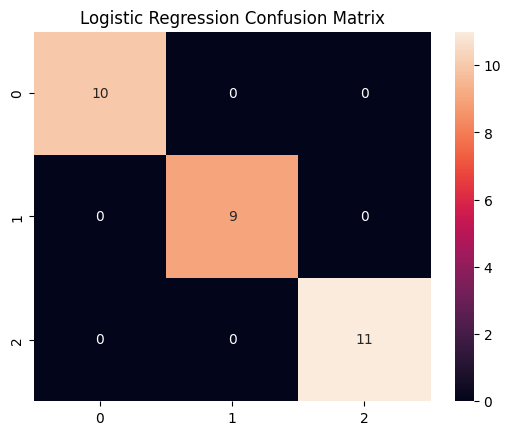

In [13]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Compare Models Table

In [14]:
results= pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


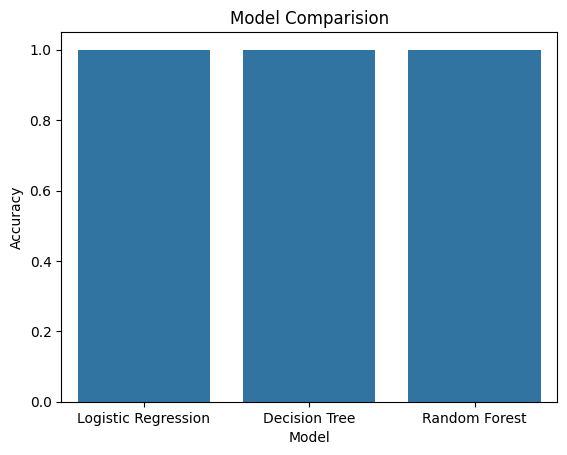

In [15]:
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Comparision")
plt.show()

# Conclusion

Three classification models were trained and evaluated on the Iris dataset.

Evaluation metrics including Accuracy, Precision, Recall, F1 Score, and Cross Validation Accuracy were used.

The model with the highest performance Logistic Regression was selected as the best model for Iris species classification.